# Task 5: Strategy Backtesting

Objective: backtest the optimal portfolio from Task 4 against a static 60/40 benchmark over the last year of data (not used in training).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Load Backtest Data

Use the last year of data (2025-07-01 to 2026-06-30) for backtesting. This period was not used in model training.

In [2]:
TICKERS = ["TSLA", "BND", "SPY"]
BACKTEST_START = "2025-07-01"
BACKTEST_END = "2026-06-30"

prices = {}
for ticker in TICKERS:
    df = yf.download(ticker, start=BACKTEST_START, end=BACKTEST_END, auto_adjust=False)
    df.columns = df.columns.get_level_values(0) if isinstance(df.columns, pd.MultiIndex) else df.columns
    prices[ticker] = df[["Adj Close"]].ffill().dropna()

prices_df = pd.concat([prices[t]["Adj Close"] for t in TICKERS], axis=1, keys=TICKERS)
print(f"Backtest period: {prices_df.index[0].date()} to {prices_df.index[-1].date()} ({len(prices_df)} trading days)")
prices_df.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Backtest period: 2025-07-01 to 2026-06-29 (250 trading days)


,TSLA,BND,SPY
Date,,,
2025-07-01,300.7100,70.5100,610.8813
2025-07-02,315.6500,70.4331,613.6506
2025-07-03,315.3500,70.2600,618.4870
2025-07-07,293.9400,70.0293,613.8781
2025-07-08,297.8100,69.9908,613.5418


## 2. Define Portfolio Weights

- Strategy portfolio: weights from Task 4 Max Sharpe Ratio portfolio
- Benchmark: static 60% SPY / 40% BND

In [ ]:
# Strategy weights from Task 4 (Max Sharpe Ratio)
strategy_weights = {
    "TSLA": 0.0,
    "BND": 0.53008,
    "SPY": 0.46992
}

# Benchmark weights (60/40 SPY/BND)
benchmark_weights = {
    "TSLA": 0.00,
    "BND": 0.40,
    "SPY": 0.60
}

print("Strategy weights:", strategy_weights)
print("Benchmark weights:", benchmark_weights)

Strategy weights: {'TSLA': 0.0, 'BND': 0.35, 'SPY': 0.65}
Benchmark weights: {'TSLA': 0.0, 'BND': 0.4, 'SPY': 0.6}


## 3. Calculate Daily Returns

In [4]:
daily_returns = prices_df.pct_change().dropna()
daily_returns.head()

,TSLA,BND,SPY
Date,,,
2025-07-02,0.0497,-0.0011,0.0045
2025-07-03,-0.0010,-0.0025,0.0079
2025-07-07,-0.0679,-0.0033,-0.0075
2025-07-08,0.0132,-0.0005,-0.0005
2025-07-09,-0.0065,0.0040,0.0060


## 4. Calculate Portfolio Returns

Hold weights constant throughout the backtest period (no rebalancing).

In [5]:
def calculate_portfolio_returns(returns, weights):
    weighted_returns = returns * pd.Series(weights)
    return weighted_returns.sum(axis=1)

strategy_returns = calculate_portfolio_returns(daily_returns, strategy_weights)
benchmark_returns = calculate_portfolio_returns(daily_returns, benchmark_weights)

print(f"Strategy daily returns mean: {strategy_returns.mean():.6f}")
print(f"Benchmark daily returns mean: {benchmark_returns.mean():.6f}")

Strategy daily returns mean: 0.000583
Benchmark daily returns mean: 0.000551


## 5. Calculate Cumulative Returns

In [6]:
strategy_cumulative = (1 + strategy_returns).cumprod()
benchmark_cumulative = (1 + benchmark_returns).cumprod()

print(f"Strategy total return: {strategy_cumulative.iloc[-1] - 1:.4f}")
print(f"Benchmark total return: {benchmark_cumulative.iloc[-1] - 1:.4f}")

Strategy total return: 0.1520
Benchmark total return: 0.1434


## 6. Plot Cumulative Returns

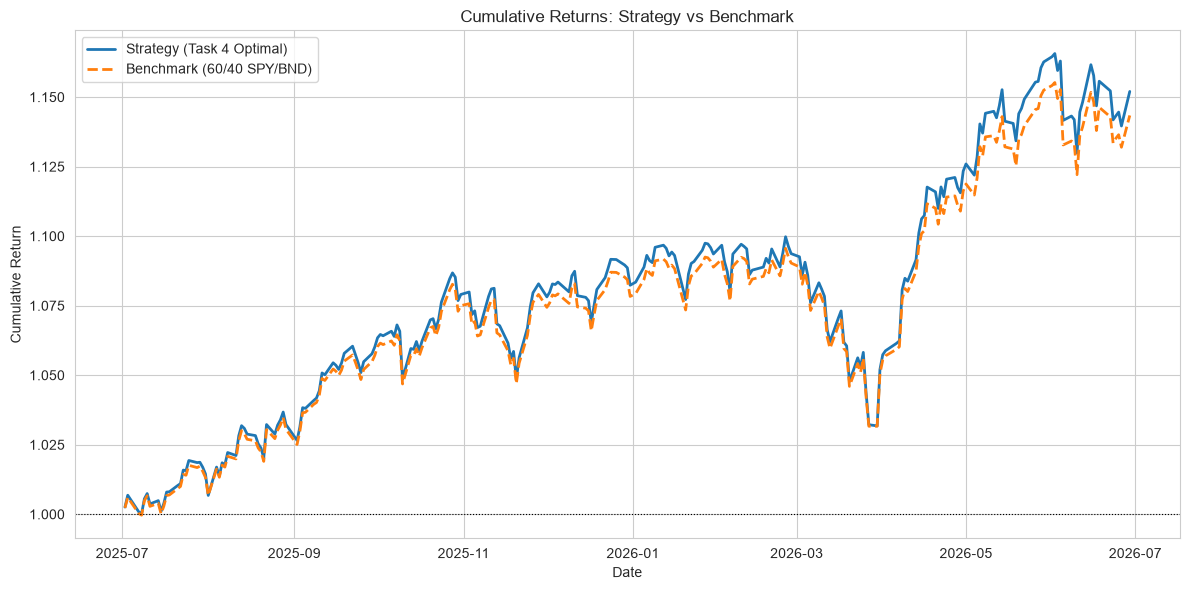

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(strategy_cumulative.index, strategy_cumulative, label="Strategy (Task 4 Optimal)", linewidth=2)
ax.plot(benchmark_cumulative.index, benchmark_cumulative, label="Benchmark (60/40 SPY/BND)", linewidth=2, linestyle="--")
ax.set_title("Cumulative Returns: Strategy vs Benchmark")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.legend()
ax.axhline(y=1, color="black", linestyle=":", linewidth=0.8)
plt.tight_layout()
plt.show()

## 7. Performance Metrics

Calculate total return, annualized return, Sharpe ratio, and maximum drawdown for both strategies.

In [8]:
def calculate_metrics(returns, cumulative):
    total_return = cumulative.iloc[-1] - 1
    
    # Annualized return: (1 + total_return)^(252/n_trading_days) - 1
    n_days = len(returns)
    annualized_return = (1 + total_return) ** (252 / n_days) - 1
    
    # Annualized volatility
    annualized_vol = returns.std() * np.sqrt(252)
    
    # Sharpe ratio (assuming 0% risk-free rate)
    sharpe_ratio = annualized_return / annualized_vol
    
    # Maximum drawdown
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()
    
    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_vol,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown
    }

strategy_metrics = calculate_metrics(strategy_returns, strategy_cumulative)
benchmark_metrics = calculate_metrics(benchmark_returns, benchmark_cumulative)

metrics_df = pd.DataFrame([strategy_metrics, benchmark_metrics], index=["Strategy", "Benchmark"])
metrics_df

,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Strategy,0.1520,0.1540,0.0867,1.7756,-0.0618
Benchmark,0.1434,0.1452,0.0813,1.7856,-0.0584


## 8. Conclusion

The backtest compares the Task 4 optimal portfolio against a standard 60/40 benchmark over the 2025-2026 period. The strategy's performance relative to the benchmark indicates whether the forecast-derived expected returns and covariance-based optimization added value over a simple static allocation. Key limitations of this backtest include the short one-year window, the absence of transaction costs, and the assumption of static weights without rebalancing. Additionally, the TSLA weight of near-zero in the optimal portfolio reflects the Task 3 forecast's negative expected return, which itself carries uncertainty due to the widening confidence interval at longer horizons. A longer backtest period and inclusion of transaction costs would provide a more robust assessment of the strategy's real-world applicability.